# Clustering con K-means

Autores: Pablo Hernández Cámara (pablo.hernandez-camara@uv.es) y Pedro Ramón Ventura Gómez (pventura@march-am.com)



En este notebook profundizaremos en el algoritmo de clustering más utilizado: K-means. Veremos cómo funciona internamente y cómo aplicarlo correctamente en problemas de segmentación.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, fetch_openml
from sklearn.preprocessing import StandardScaler
import time

# Configuración estética
plt.style.use('ggplot')

## K-means "A Mano"



Para entender la lógica de los centroides, implementaremos el algoritmo básico. K-means sigue estos pasos:

1. Inicializar centroides aleatorios.

2. Asignar cada punto al centroide más cercano.

3. Actualizar los centroides calculando la media de los puntos asignados.

4. Repetir hasta convergencia.

**Ejercicio: Para medir la distancia entre los datos y los centroides, k-means utiliza la distancia euclidea. Programa una función que la calcule.**

Primero necesitamos los datos, vamos a generarlos.

In [ ]:
X_synth, _ = make_blobs(n_samples=1000, centers=4, cluster_std=0.60, random_state=0)
print(X_synth.shape)

(1000, 2)


**Ejercicio: Representa los datos. ¿Cuantos clusters dirias que hay?**

Vamos a hacer k-means a mano! Acordaros de que k-means necesita definir previamente el número de clusters a encontrar, k.

In [ ]:
k = 4

# 1. Inicialización aleatoria de centroides
n_samples, n_features = X_synth.shape
idx = np.random.choice(n_samples, k, replace=False)
centroids = X_synth[idx]
print(centroids)

[[ 2.06044426  1.21386619]
 [-1.08869294  3.58062935]
 [-1.62783255  3.14462832]
 [-0.41393539  6.85065085]]


**Ejercicio: Representa estos primeros centroides aleatorios.**

Y ahora si, vamos a iterar.

In [ ]:
max_iters = 5

for i in range(max_iters):
    # 2. Asignación: ¿A qué centroide pertenece cada punto?
    clusters = []
    for x in X_synth:
        distancias = distancia_euclidea(x.reshape(1, -1), centroids)
        cluster_id = np.argmin(distancias)
        clusters.append(cluster_id)

    clusters = np.array(clusters)
    old_centroids = centroids.copy()

    # 3. Actualización: Mover el centroide a la media del grupo
    for j in range(k):
        points_in_cluster = X_synth[clusters == j]
        if len(points_in_cluster) > 0:
            centroids[j] = points_in_cluster.mean(axis=0)

    # 4. Condición de parada si no hay cambios
    if np.all(old_centroids == centroids):
        print(f"Convergió en la iteración {i}")
        break

Convergió en la iteración 4


**Ejercicio: Representa los clusters finales y sus centroides correspondientes**

**Ejercicio: Prueba a añadir el plot dentro del bucle para ir viendo como van cambiando.**

In [ ]:
max_iters = 5

for i in range(max_iters):
    # 2. Asignación: ¿A qué centroide pertenece cada punto?
    clusters = []
    for x in X_synth:
        distancias = distancia_euclidea(x.reshape(1, -1), centroids)
        cluster_id = np.argmin(distancias)
        clusters.append(cluster_id)

    clusters = np.array(clusters)
    old_centroids = centroids.copy()

    # 3. Actualización: Mover el centroide a la media del grupo
    for j in range(k):
        points_in_cluster = X_synth[clusters == j]
        if len(points_in_cluster) > 0:
            centroids[j] = points_in_cluster.mean(axis=0)

    # 4. Condición de parada si no hay cambios
    if np.all(old_centroids == centroids):
        print(f"Convergió en la iteración {i}")
        break

    plt.scatter(X_synth[:, 0], X_synth[:, 1], c=clusters, s=50, cmap='viridis')
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, alpha=0.5, marker='X')
    plt.title("K-means Manual")
    plt.show()

Convergió en la iteración 0


## K-means con Scikit-Learn

Esto que hemos programado a mano, podemos usarlo directamente de la función de sklearn.

**Ejercicio: Vamos a complicar un poco los datos, sube a 6 clusters y aumenta el cluster std. ¿Que hace este último valor?**

**Ejercicio: Usa la función de sklearn, k-means, con k=5 para encontrar los clusters. Representa el resultado y los centros de los clusters.**

**Ejercicio: Prueba a ejecutarlo varias veces con distintas semillas. ¿Cambia el resultado? ¿Por que?**

**Ejercicio: ¿Como se soluciona esto? ¿Que hace el parametro n_init? ¿Y 'init'?**

Pero... ¿y si no sabemos cuantos clusters tenemos a priori? Aqui es muy sencillo verlo, pero puede no ser tan facil si tenemos muchas dimensiones.

**Ejercicio: Una posible técnica para ver que número de clusters es el óptimo es el método del codo, que k-means nos devuelve en .intertia_. Representalo según el número k.**

## K-means in real data

In [ ]:
raw_data = fetch_openml(name='credit-g', version=1, as_frame=True)
X_credit = raw_data.data.select_dtypes(include=[np.number])
print(X_credit.shape)

(1000, 7)


En los casos anteriores como eran datos sintéticos no nos hemos preocupado de normalizarlos, pero esto es imprescindible cuando usemos k-means con datos reales. Si no unas variables dominarán sobre otras.

**Ejercicio: Estandariza los datos.**

**Ejercicio: Ejecuta k-means con k=3.**

**Ejercicio: ¿Como podemos interpretar estos grupos?**

**Ejercicio: ¿Que podriamos hacer para visualizarlos?**

## K-means problemas

Vamos a generar algunos datos nuevos.

In [ ]:
n_samples = 1500
random_state = 170
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]

X, y = make_blobs(n_samples=n_samples, random_state=random_state)
X_aniso = np.dot(X, transformation)  # Anisotropic
X_varied, y_varied = make_blobs(n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state)  # Unequal variance
X_filtered = np.vstack((X[y == 0][:500], X[y == 1][:100], X[y == 2][:10]))  # Unevenly sized blobs
y_filtered = [0] * 500 + [1] * 100 + [2] * 10

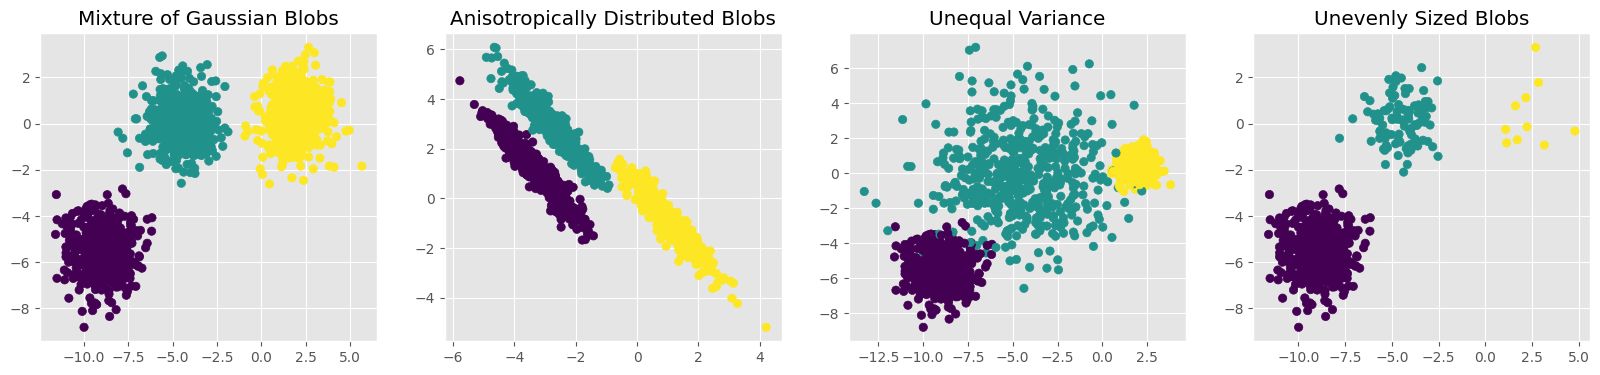

In [ ]:
fig, axs = plt.subplots(1,4, figsize=(20, 4))
axs[0].scatter(X[:, 0], X[:, 1], c=y)
axs[0].set_title("Mixture of Gaussian Blobs")
axs[1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y)
axs[1].set_title("Anisotropically Distributed Blobs")
axs[2].scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied)
axs[2].set_title("Unequal Variance")
axs[3].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_filtered)
axs[3].set_title("Unevenly Sized Blobs")
plt.show()

**Ejercicio: Aplica k-means en cada uno de los datasets, con k=3 y n_init=auto. ¿Te convencen los resultados?**

**Ejercicio: ¿Posibles soluciones?**